# Compare Built-In PTQ And Custom PTQ: ResNet-18

This notebook compares built-in TensorFlow Lite INT8 PTQ and custom 8-bit PTQ on the same pretrained ResNet-18 model and the same CIFAR-10 representative inputs.

CIFAR-10 is used only as representative input data. The model is pretrained on ImageNet, so CIFAR-10 labels are not used for accuracy.


## Setup


In [1]:
from pathlib import Path
import importlib
import json
import sys

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
PROJECT_ROOT


PosixPath('/Users/sahil/Group Studies/Quantization-Group-Studies')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow import keras

from src.models import load_pretrained_resnet18
from src.quantization import (
    build_fixed_input_model,
    convert_dynamic_range,
    convert_float,
    convert_full_integer,
)

import src.evaluation.tflite_metrics as tflite_metrics
custom_ptq_module = importlib.import_module(
    "src.quantization.custom_quantization.custom_ptq"
)

tflite_metrics = importlib.reload(tflite_metrics)
custom_ptq_module = importlib.reload(custom_ptq_module)

inspect_tflite = tflite_metrics.inspect_tflite
predict_tflite = tflite_metrics.predict_tflite
reduction_metrics = tflite_metrics.reduction_metrics
size_metrics = tflite_metrics.size_metrics
custom_ptq = custom_ptq_module.custom_ptq
dequantize_tensor = custom_ptq_module.dequantize_tensor


/Users/sahil/Group Studies/Quantization-Group-Studies/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load CIFAR-10 Representative Inputs


In [3]:
(cifar_train_images, cifar_train_labels), _ = keras.datasets.cifar10.load_data()

num_cifar_samples = 100
raw_images = [
    np.asarray(
        Image.fromarray(image).resize((224, 224), Image.Resampling.BILINEAR),
        dtype=np.uint8,
    )[None, ...]
    for image in cifar_train_images[:num_cifar_samples]
]
cifar_labels = cifar_train_labels[:num_cifar_samples].reshape(-1)

len(raw_images), raw_images[0].shape, raw_images[0].dtype, cifar_labels[:10]


(100,
 (1, 224, 224, 3),
 dtype('uint8'),
 array([6, 9, 9, 4, 1, 1, 2, 7, 8, 3], dtype=uint8))

## Load Model And Preprocess Samples


In [4]:
model = load_pretrained_resnet18()
fixed_model = build_fixed_input_model(model)

samples = [np.asarray(model.preprocessor(image), dtype=np.float32) for image in raw_images]
samples[0].shape, samples[0].dtype


((1, 224, 224, 3), dtype('float32'))

## Built-In PTQ Models

This cell reconverts the TFLite models so the comparison uses the current converter settings. In particular, `full_int8` uses INT8 model input and output.


In [5]:
output_dir = PROJECT_ROOT / "artifacts" / "resnet18_ptq_comparison_notebook"
output_dir.mkdir(parents=True, exist_ok=True)

paths = {
    "float32": output_dir / "resnet18_float32.tflite",
    "builtin_dynamic_int8": output_dir / "resnet18_dynamic_int8.tflite",
    "builtin_full_int8": output_dir / "resnet18_full_int8.tflite",
}

def representative_dataset():
    for sample in samples:
        yield [sample]

paths["float32"].write_bytes(convert_float(fixed_model))
paths["builtin_dynamic_int8"].write_bytes(convert_dynamic_range(fixed_model))
paths["builtin_full_int8"].write_bytes(convert_full_integer(fixed_model, representative_dataset))

{name: path.stat().st_size for name, path in paths.items()}


INFO:tensorflow:Assets written to: /var/folders/s8/_c97b0k12817pts24pvmjr480000gn/T/tmp1uj4bqph/assets


INFO:tensorflow:Assets written to: /var/folders/s8/_c97b0k12817pts24pvmjr480000gn/T/tmp1uj4bqph/assets


Saved artifact at '/var/folders/s8/_c97b0k12817pts24pvmjr480000gn/T/tmp1uj4bqph'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(None, 1000), dtype=tf.float32, name=None)
Captures:
  4819003024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4819003600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4819003408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4819003984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4819002640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4819003216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4819004752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4819004560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4819004944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4819002832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4819004176: TensorSpec(

W0000 00:00:1783633859.769616 11288512 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1783633859.769627 11288512 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-07-09 23:50:59.769817: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/s8/_c97b0k12817pts24pvmjr480000gn/T/tmp1uj4bqph
2026-07-09 23:50:59.771465: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-07-09 23:50:59.771470: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/s8/_c97b0k12817pts24pvmjr480000gn/T/tmp1uj4bqph
I0000 00:00:1783633859.785851 11288512 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
2026-07-09 23:50:59.788681: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-07-09 23:50:59.902917: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /var/fol

INFO:tensorflow:Assets written to: /var/folders/s8/_c97b0k12817pts24pvmjr480000gn/T/tmp6jxkanad/assets


...

INFO:tensorflow:Assets written to: /var/folders/s8/_c97b0k12817pts24pvmjr480000gn/T/tmpcoerp5l4/assets


INFO:tensorflow:Assets written to: /var/folders/s8/_c97b0k12817pts24pvmjr480000gn/T/tmpcoerp5l4/assets


Saved artifact at '/var/folders/s8/_c97b0k12817pts24pvmjr480000gn/T/tmpcoerp5l4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(None, 1000), dtype=tf.float32, name=None)
Captures:
  4819003024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4819003600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4819003408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4819003984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4819002640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4819003216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4819004752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4819004560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4819004944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4819002832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4819004176: TensorSpec(

/Users/sahil/Group Studies/Quantization-Group-Studies/.venv/lib/python3.13/site-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1783633865.051791 11288512 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1783633865.051801 11288512 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-07-09 23:51:05.051882: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/s8/_c97b0k12817pts24pvmjr480000gn/T/tmpcoerp5l4
2026-07-09 23:51:05.053462: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-07-09 23:51:05.053467: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/s8/_c97b0k12817pts24pvmjr480000gn/T/tmpcoerp5l4
2026-07-09 23:51:05.069230: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-07-0

{'float32': 46757588,
 'builtin_dynamic_int8': 11790840,
 'builtin_full_int8': 11862088}

## Built-In PTQ Metrics


In [6]:
builtin_results = {}

for name, path in paths.items():
    metrics = {
        "dataset": "cifar10",
        "num_calibration_samples": len(samples),
        **inspect_tflite(path),
        **predict_tflite(path, samples[0]),
    }

    if name == "float32":
        size_bytes = path.stat().st_size
        metrics.update({
            "size_bytes": size_bytes,
            "size_mib": size_bytes / (1024 ** 2),
            "compression_ratio": 1.0,
            "memory_reduction_percent": 0.0,
        })
    else:
        metrics.update(size_metrics(paths["float32"], path))

    builtin_results[name] = metrics

baseline = builtin_results["float32"]
for metrics in builtin_results.values():
    metrics["weight_memory"] = {
        "size_bytes": metrics["weight_storage_bytes"],
        **reduction_metrics(baseline["weight_storage_bytes"], metrics["weight_storage_bytes"]),
    }
    metrics["activation_memory"] = {
        "tensor_storage_bytes": metrics["activation_tensor_storage_bytes"],
        "largest_tensor_bytes": metrics["largest_activation_tensor_bytes"],
        **reduction_metrics(
            baseline["activation_tensor_storage_bytes"],
            metrics["activation_tensor_storage_bytes"],
        ),
    }

pd.DataFrame([
    {
        "model": name,
        "size_mib": metrics["size_mib"],
        "serialized_compression": metrics["compression_ratio"],
        "serialized_reduction_%": metrics["memory_reduction_percent"],
        "weight_reduction_%": metrics["weight_memory"]["memory_reduction_percent"],
        "activation_reduction_%": metrics["activation_memory"]["memory_reduction_percent"],
        "top_class_index": metrics["top_class_index"],
        "input_dtype": metrics["input_dtype"],
        "output_dtype": metrics["output_dtype"],
    }
    for name, metrics in builtin_results.items()
])


/Users/sahil/Group Studies/Quantization-Group-Studies/.venv/lib/python3.13/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


,model,size_mib,serialized_compression,serialized_reduction_%,weight_reduction_%,activation_reduction_%,top_class_index,input_dtype,output_dtype
0,float32,44.591511,1.000000,0.000000,0.000000,0.0,371,float32,float32
1,builtin_dynamic_int8,11.244621,3.965586,74.783045,74.962656,0.0,371,float32,float32
2,builtin_full_int8,11.312569,3.941767,74.630667,74.962656,75.0,371,int8,int8


## Custom 8-Bit PTQ


In [7]:
quantize_min_rank = 2
per_channel = True
custom_results = custom_ptq(
    model,
    samples,
    quantize_min_rank=quantize_min_rank,
    per_channel=per_channel,
)

weight_result = custom_results["weights"]
activation_result = custom_results["activations"]

len(weight_result.tensors), len(activation_result.ranges)


(21, 5)

## Prediction Preservation Comparison


In [8]:
fp32_output = model(samples[0], training=False).numpy()
fp32_top_class = int(np.argmax(fp32_output[0]))

prediction_rows = [
    {
        "model": "float32_keras",
        "dataset": "cifar10",
        "cifar10_label": int(cifar_labels[0]),
        "top_class_index": fp32_top_class,
        "matches_fp32_prediction": True,
        "max_abs_output_difference": 0.0,
    }
]

for name in ["builtin_dynamic_int8", "builtin_full_int8"]:
    top_class = builtin_results[name]["top_class_index"]
    prediction_rows.append(
        {
            "model": name,
            "dataset": "cifar10",
            "cifar10_label": int(cifar_labels[0]),
            "top_class_index": top_class,
            "matches_fp32_prediction": top_class == fp32_top_class,
            "max_abs_output_difference": None,
        }
    )

quantized_tensor_iter = iter(weight_result.tensors)
dequantized_weights = []
round_trip_rows = []
coverage_rows = []

for weight in model.weights:
    weight_array = weight.numpy()
    should_dequantize = (
        np.issubdtype(weight_array.dtype, np.floating)
        and weight_array.ndim >= quantize_min_rank
    )
    coverage_rows.append(
        {
            "name": weight.name,
            "shape": tuple(weight_array.shape),
            "rank": weight_array.ndim,
            "dtype": str(weight_array.dtype),
            "quantized": should_dequantize,
        }
    )

    if should_dequantize:
        quantized_tensor = next(quantized_tensor_iter)
        dequantized = dequantize_tensor(quantized_tensor).astype(weight_array.dtype)
        dequantized_weights.append(dequantized)
        diff = np.abs(weight_array - dequantized)
        round_trip_rows.append(
            {
                "name": weight.name,
                "shape": tuple(weight_array.shape),
                "quantization_axis": quantized_tensor.quantization_axis,
                "scale_count": int(np.size(quantized_tensor.scale)),
                "max_abs_error": float(np.max(diff)),
                "mean_abs_error": float(np.mean(diff)),
            }
        )
    else:
        dequantized_weights.append(weight_array)

remaining_quantized_tensors = list(quantized_tensor_iter)
if remaining_quantized_tensors:
    raise ValueError(
        f"Did not consume {len(remaining_quantized_tensors)} quantized tensors."
    )

custom_dequantized_model = load_pretrained_resnet18()
custom_dequantized_model.set_weights(dequantized_weights)
custom_output = custom_dequantized_model(samples[0], training=False).numpy()
custom_top_class = int(np.argmax(custom_output[0]))

prediction_rows.append(
    {
        "model": "custom_8bit_dequantized",
        "dataset": "cifar10",
        "cifar10_label": int(cifar_labels[0]),
        "top_class_index": custom_top_class,
        "matches_fp32_prediction": custom_top_class == fp32_top_class,
        "max_abs_output_difference": float(np.max(np.abs(fp32_output - custom_output))),
    }
)

prediction_table = pd.DataFrame(prediction_rows)
coverage_table = pd.DataFrame(coverage_rows)
round_trip_table = pd.DataFrame(round_trip_rows)
prediction_table


,model,dataset,cifar10_label,top_class_index,matches_fp32_prediction,max_abs_output_difference
0,float32_keras,cifar10,6,371,True,0.000000
1,builtin_dynamic_int8,cifar10,6,371,True,NaN
2,builtin_full_int8,cifar10,6,371,True,NaN
3,custom_8bit_dequantized,cifar10,6,371,True,1.187952


## Custom Weight Diagnostics

These tables check weight round-trip quality and quantization coverage before plotting predictions.


In [9]:
coverage_table["quantized"].value_counts().rename_axis("quantized").reset_index(name="num_tensors")


,quantized,num_tensors
0,False,81
1,True,21


In [10]:
round_trip_table.sort_values("max_abs_error", ascending=False).head(10)


,name,shape,quantization_axis,scale_count,max_abs_error,mean_abs_error
1,kernel,"(3, 3, 64, 64)",-1,64,0.027875,0.003853
0,kernel,"(7, 7, 3, 64)",-1,64,0.026960,0.001996
19,kernel,"(3, 3, 512, 512)",-1,512,0.019236,0.002483
13,kernel,"(3, 3, 256, 256)",-1,256,0.018784,0.003237
18,kernel,"(3, 3, 512, 512)",-1,512,0.018470,0.002643
16,kernel,"(1, 1, 256, 512)",-1,512,0.017772,0.002089
3,kernel,"(3, 3, 64, 64)",-1,64,0.015756,0.003575
17,kernel,"(3, 3, 512, 512)",-1,512,0.015623,0.002548
12,kernel,"(3, 3, 256, 256)",-1,256,0.014972,0.003291
2,kernel,"(3, 3, 64, 64)",-1,64,0.014617,0.002846


## Top-5 Logit Comparison


In [11]:
def top_k_table(output, model_name, k=5):
    indices = np.argsort(output[0])[-k:][::-1]
    return pd.DataFrame({
        "model": model_name,
        "rank": range(1, k + 1),
        "class_index": indices.astype(int),
        "logit": output[0][indices].astype(float),
    })

top5_table = pd.concat([
    top_k_table(fp32_output, "float32_keras"),
    top_k_table(custom_output, "custom_8bit_dequantized"),
], ignore_index=True)
top5_table


,model,rank,class_index,logit
0,float32_keras,1,371,-0.883369
1,float32_keras,2,577,-1.187277
2,float32_keras,3,860,-2.374426
3,float32_keras,4,62,-3.165583
4,float32_keras,5,901,-3.287360
5,custom_8bit_dequantized,1,371,-0.813803
6,custom_8bit_dequantized,2,577,-1.685302
7,custom_8bit_dequantized,3,860,-3.090141
8,custom_8bit_dequantized,4,635,-3.482928
9,custom_8bit_dequantized,5,373,-3.512285


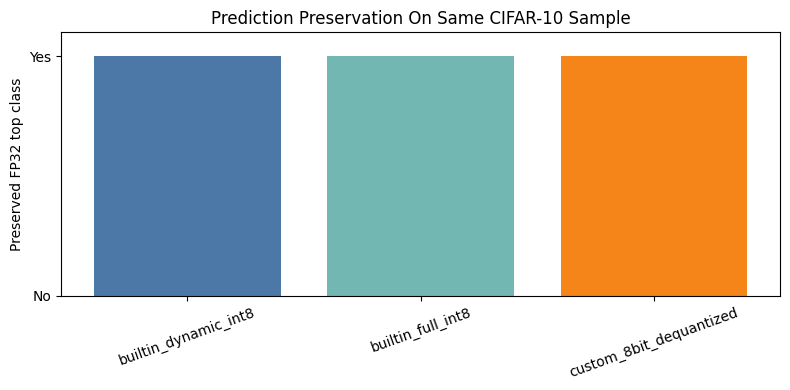

In [12]:
plot_df = prediction_table[prediction_table["model"] != "float32_keras"].copy()
plot_df["prediction_preserved"] = plot_df["matches_fp32_prediction"].astype(int)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(plot_df["model"], plot_df["prediction_preserved"], color=["#4C78A8", "#72B7B2", "#F58518"])
ax.set_ylim(0, 1.1)
ax.set_ylabel("Preserved FP32 top class")
ax.set_title("Prediction Preservation On Same CIFAR-10 Sample")
ax.set_yticks([0, 1])
ax.set_yticklabels(["No", "Yes"])
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()


## Metric Comparison Tables


In [13]:
metric_rows = []

for name in ["builtin_dynamic_int8", "builtin_full_int8"]:
    metrics = builtin_results[name]
    metric_rows.append(
        {
            "method": name,
            "weight_compression": metrics["weight_memory"]["compression_ratio"],
            "weight_reduction_%": metrics["weight_memory"]["memory_reduction_percent"],
            "activation_compression": metrics["activation_memory"]["compression_ratio"],
            "activation_reduction_%": metrics["activation_memory"]["memory_reduction_percent"],
            "serialized_compression": metrics["compression_ratio"],
            "serialized_reduction_%": metrics["memory_reduction_percent"],
        }
    )

metric_rows.append(
    {
        "method": "custom_8bit_per_channel",
        "weight_compression": weight_result.compression_ratio,
        "weight_reduction_%": weight_result.memory_reduction_percent,
        "activation_compression": activation_result.compression_ratio,
        "activation_reduction_%": activation_result.memory_reduction_percent,
        "serialized_compression": None,
        "serialized_reduction_%": None,
    }
)

metrics_table = pd.DataFrame(metric_rows)
metrics_table


,method,weight_compression,weight_reduction_%,activation_compression,activation_reduction_%,serialized_compression,serialized_reduction_%
0,builtin_dynamic_int8,3.994034,74.962656,1.0,0.0,3.965586,74.783045
1,builtin_full_int8,3.994034,74.962656,4.0,75.0,3.941767,74.630667
2,custom_8bit_per_channel,3.979387,74.870503,4.0,75.0,NaN,NaN


## Metric Graphs


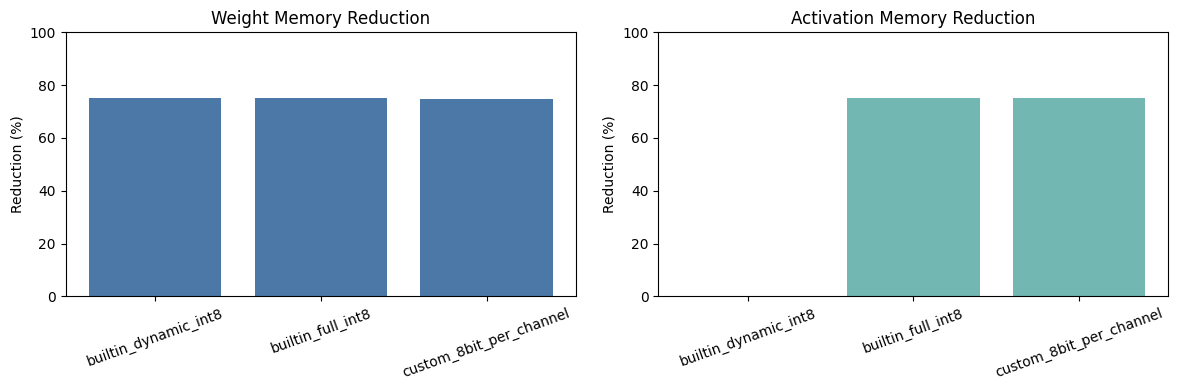

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(metrics_table["method"], metrics_table["weight_reduction_%"], color="#4C78A8")
axes[0].set_title("Weight Memory Reduction")
axes[0].set_ylabel("Reduction (%)")
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(metrics_table["method"], metrics_table["activation_reduction_%"], color="#72B7B2")
axes[1].set_title("Activation Memory Reduction")
axes[1].set_ylabel("Reduction (%)")
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()


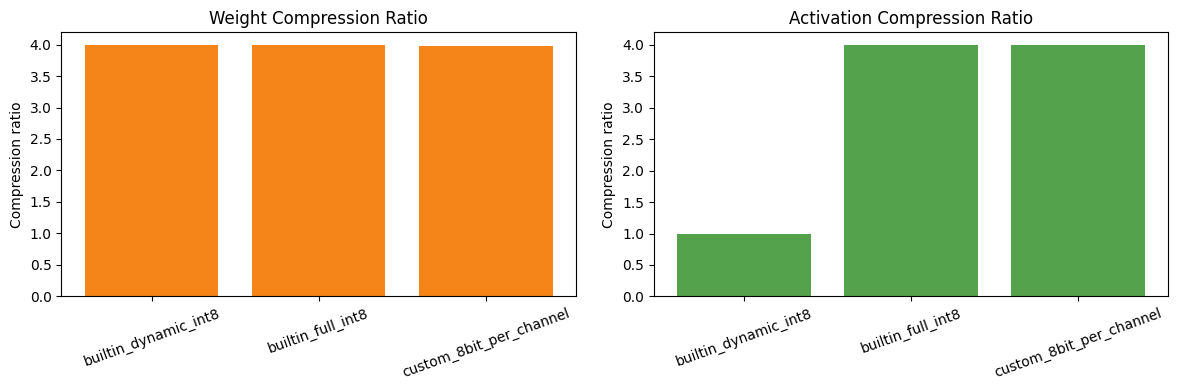

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(metrics_table["method"], metrics_table["weight_compression"], color="#F58518")
axes[0].set_title("Weight Compression Ratio")
axes[0].set_ylabel("Compression ratio")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(metrics_table["method"], metrics_table["activation_compression"], color="#54A24B")
axes[1].set_title("Activation Compression Ratio")
axes[1].set_ylabel("Compression ratio")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()


## Save Comparison Results


In [16]:
comparison_dir = PROJECT_ROOT / "artifacts" / "resnet18_ptq_comparison_notebook"
comparison_dir.mkdir(parents=True, exist_ok=True)

prediction_path = comparison_dir / "prediction_comparison.csv"
metrics_path = comparison_dir / "metrics_comparison.csv"
coverage_path = comparison_dir / "custom_weight_coverage.csv"
round_trip_path = comparison_dir / "custom_weight_round_trip.csv"
summary_path = comparison_dir / "comparison_summary.json"

prediction_table.to_csv(prediction_path, index=False)
metrics_table.to_csv(metrics_path, index=False)
coverage_table.to_csv(coverage_path, index=False)
round_trip_table.to_csv(round_trip_path, index=False)

summary = {
    "dataset": "cifar10",
    "num_calibration_samples": len(samples),
    "custom_quantize_min_rank": quantize_min_rank,
    "custom_per_channel": per_channel,
    "prediction_comparison_csv": str(prediction_path.relative_to(PROJECT_ROOT)),
    "metrics_comparison_csv": str(metrics_path.relative_to(PROJECT_ROOT)),
    "custom_weight_coverage_csv": str(coverage_path.relative_to(PROJECT_ROOT)),
    "custom_weight_round_trip_csv": str(round_trip_path.relative_to(PROJECT_ROOT)),
    "prediction_records": prediction_table.to_dict(orient="records"),
    "metric_records": metrics_table.where(pd.notnull(metrics_table), None).to_dict(orient="records"),
}
summary_path.write_text(json.dumps(summary, indent=2) + "\n", encoding="utf-8")

prediction_path, metrics_path, coverage_path, round_trip_path, summary_path


(PosixPath('/Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/resnet18_ptq_comparison_notebook/prediction_comparison.csv'),
 PosixPath('/Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/resnet18_ptq_comparison_notebook/metrics_comparison.csv'),
 PosixPath('/Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/resnet18_ptq_comparison_notebook/custom_weight_coverage.csv'),
 PosixPath('/Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/resnet18_ptq_comparison_notebook/custom_weight_round_trip.csv'),
 PosixPath('/Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/resnet18_ptq_comparison_notebook/comparison_summary.json'))

## Notes

- Built-in dynamic INT8 and full INT8 are executable TFLite models.
- Custom 8-bit PTQ is evaluated by dequantizing custom per-channel INT8 weights into a copied Keras model and checking prediction preservation.
- CIFAR-10 labels are kept as metadata only. They are not accuracy labels for this ImageNet-pretrained ResNet-18 model.
- Built-in and custom activation memory estimates are not identical measurement methods; compare them as study estimates, not exact runtime peak memory.
- The coverage and round-trip tables help debug whether custom quantization touched the intended tensors and how much numerical error each dequantized tensor introduced.
